# Multi-Agent Debate System: Live Dataset Evaluation & Accuracy Benchmark

This notebook evaluates your dataset using the Multi-Agent Debate framework and visualizes **Single Agent** vs **Multi-Agent Debate** performance across various benchmark datasets (**Grade School Math**, **MMLU**, **Arithmetic**, **Biographies**, **Chess Move Validity**, **Chess Move Optimality**).

### Evaluation Strategies Tested:
1. **Single Agent**: Direct baseline query execution.
2. **Single Agent (Reflection)**: Single agent 2-round self-reflection & critique.
3. **Multiagent (Majority)**: 3 heterogeneous agents with parallel responses and majority voting.
4. **Multiagent (Debate)**: 3 heterogeneous agents executing iterative cross-examination, critique, and consensus synthesis.

In [1]:
import sys
import os
import json
import asyncio
import nest_asyncio
from dotenv import load_dotenv

# Apply nest_asyncio to support async execution in Jupyter notebook environment
nest_asyncio.apply()
sys.stdout.reconfigure(encoding='utf-8')

# Load API Keys
load_dotenv()

print("Environment initialized successfully.")

AttributeError: 'OutStream' object has no attribute 'reconfigure'

## 1. Import Framework & Evaluation Modules

In [4]:
from models.model_manager import ModelManager
from execution.query_execution import ExecutionController
from evaluation.dataset_evaluator import DatasetLoader, AnswerExtractor, BenchmarkEvaluator
from evaluation.visualization import DebateVisualizer

visualizer = DebateVisualizer()
print("Evaluation framework modules imported successfully.")

Evaluation framework modules imported successfully.


## 2. Load Evaluation Datasets
Loading questions from GSM8K (`Dataset/grade-school-math`), MMLU (`Dataset/mmlu`), Arithmetic, Biographies, and Chess Move reasoning datasets.

In [5]:
# Load standard benchmark suite
suite = DatasetLoader.get_benchmark_suite()

print(f"Loaded {len(suite)} datasets for evaluation:")
for dataset_name, items in suite.items():
    print(f" - {dataset_name}: {len(items)} evaluation samples")
    print(f"   Sample Question: {items[0]['question'][:75]}...")
    print(f"   Target Answer:   {items[0]['target']}")

Loaded 6 datasets for evaluation:
 - Biographies: 3 evaluation samples
   Sample Question: Which university did Albert Einstein earn his PhD from in 1905?...
   Target Answer:   University of Zurich
 - MMLU: 3 evaluation samples
   Sample Question: Which of the following data structures operates on a Last In, First Out (LI...
   Target Answer:   B
 - Chess Move Validity: 3 evaluation samples
   Sample Question: In standard chess from the starting position, is the move e2 to e4 a valid ...
   Target Answer:   Yes
 - Arithmetic: 3 evaluation samples
   Sample Question: What is 17 * 14 - 39 + 112 / 4?...
   Target Answer:   227
 - Grade School Math: 3 evaluation samples
   Sample Question: Janet’s ducks lay 16 eggs per day. She eats three for breakfast every morni...
   Target Answer:   18
 - Chess Move Optimality: 2 evaluation samples
   Sample Question: White has Queen on d1, Black King on e8 with no defending pieces. White pla...
   Target Answer:   Yes


## 3. Run Live Dataset Evaluation Across All Strategies
Executing single-agent baseline, self-reflection, majority voting, and 3-agent iterative debate on your dataset.

In [6]:
evaluator = BenchmarkEvaluator()

# Execute evaluation across all benchmark datasets
benchmark_results = await evaluator.run_full_suite_benchmark(suite)

print("Live dataset evaluation completed successfully.")


Evaluating Benchmark Dataset: Biographies (3 samples)
Sample [1/3]: Which university did Albert Einstein earn his PhD from in 19...

--- Round 1: Initial Arguments for query: 'Which university did Albert Einstein earn his PhD from in 1905?' ---
[agent_1 (llama-3.3-70b-versatile)] Final Answer: 'University of Zurich' | Confidence: 0.95
[agent_2 (qwen/qwen-2.5-72b-instruct)] Final Answer: 'University of Zurich' | Confidence: 0.95
[agent_3 (llama-3.1-8b-instant)] Final Answer: 'University of Zurich' | Confidence: 1.0

⚡ [Dynamic Early Exit Tripwire] All active agents agreed on 'University of Zurich' with average confidence 0.97 in Round 1. Terminating debate loop early.

--- Final Phase: Impartial Consensus Evaluation ---

[agent_judge] Impartial Consensus Synthesized | Final Answer: 'University of Zurich' | Confidence Score: 0.997
Sample [2/3]: Who was the primary architect of the Indian Constitution?...

--- Round 1: Initial Arguments for query: 'Who was the primary architect of the In

## 4. Single Agent vs. Multi-Agent Debate Accuracy Bar Chart
Rendering the dual bar chart (**Blue** for Single Agent, **Red** for Multi-Agent Debate) computed directly from your dataset evaluation results.

findfont: Failed to find font weight medium, now using 400.
findfont: Failed to find font weight medium, now using 400.


Bar chart successfully saved to results/graphs\accuracy_comparison_barchart.png


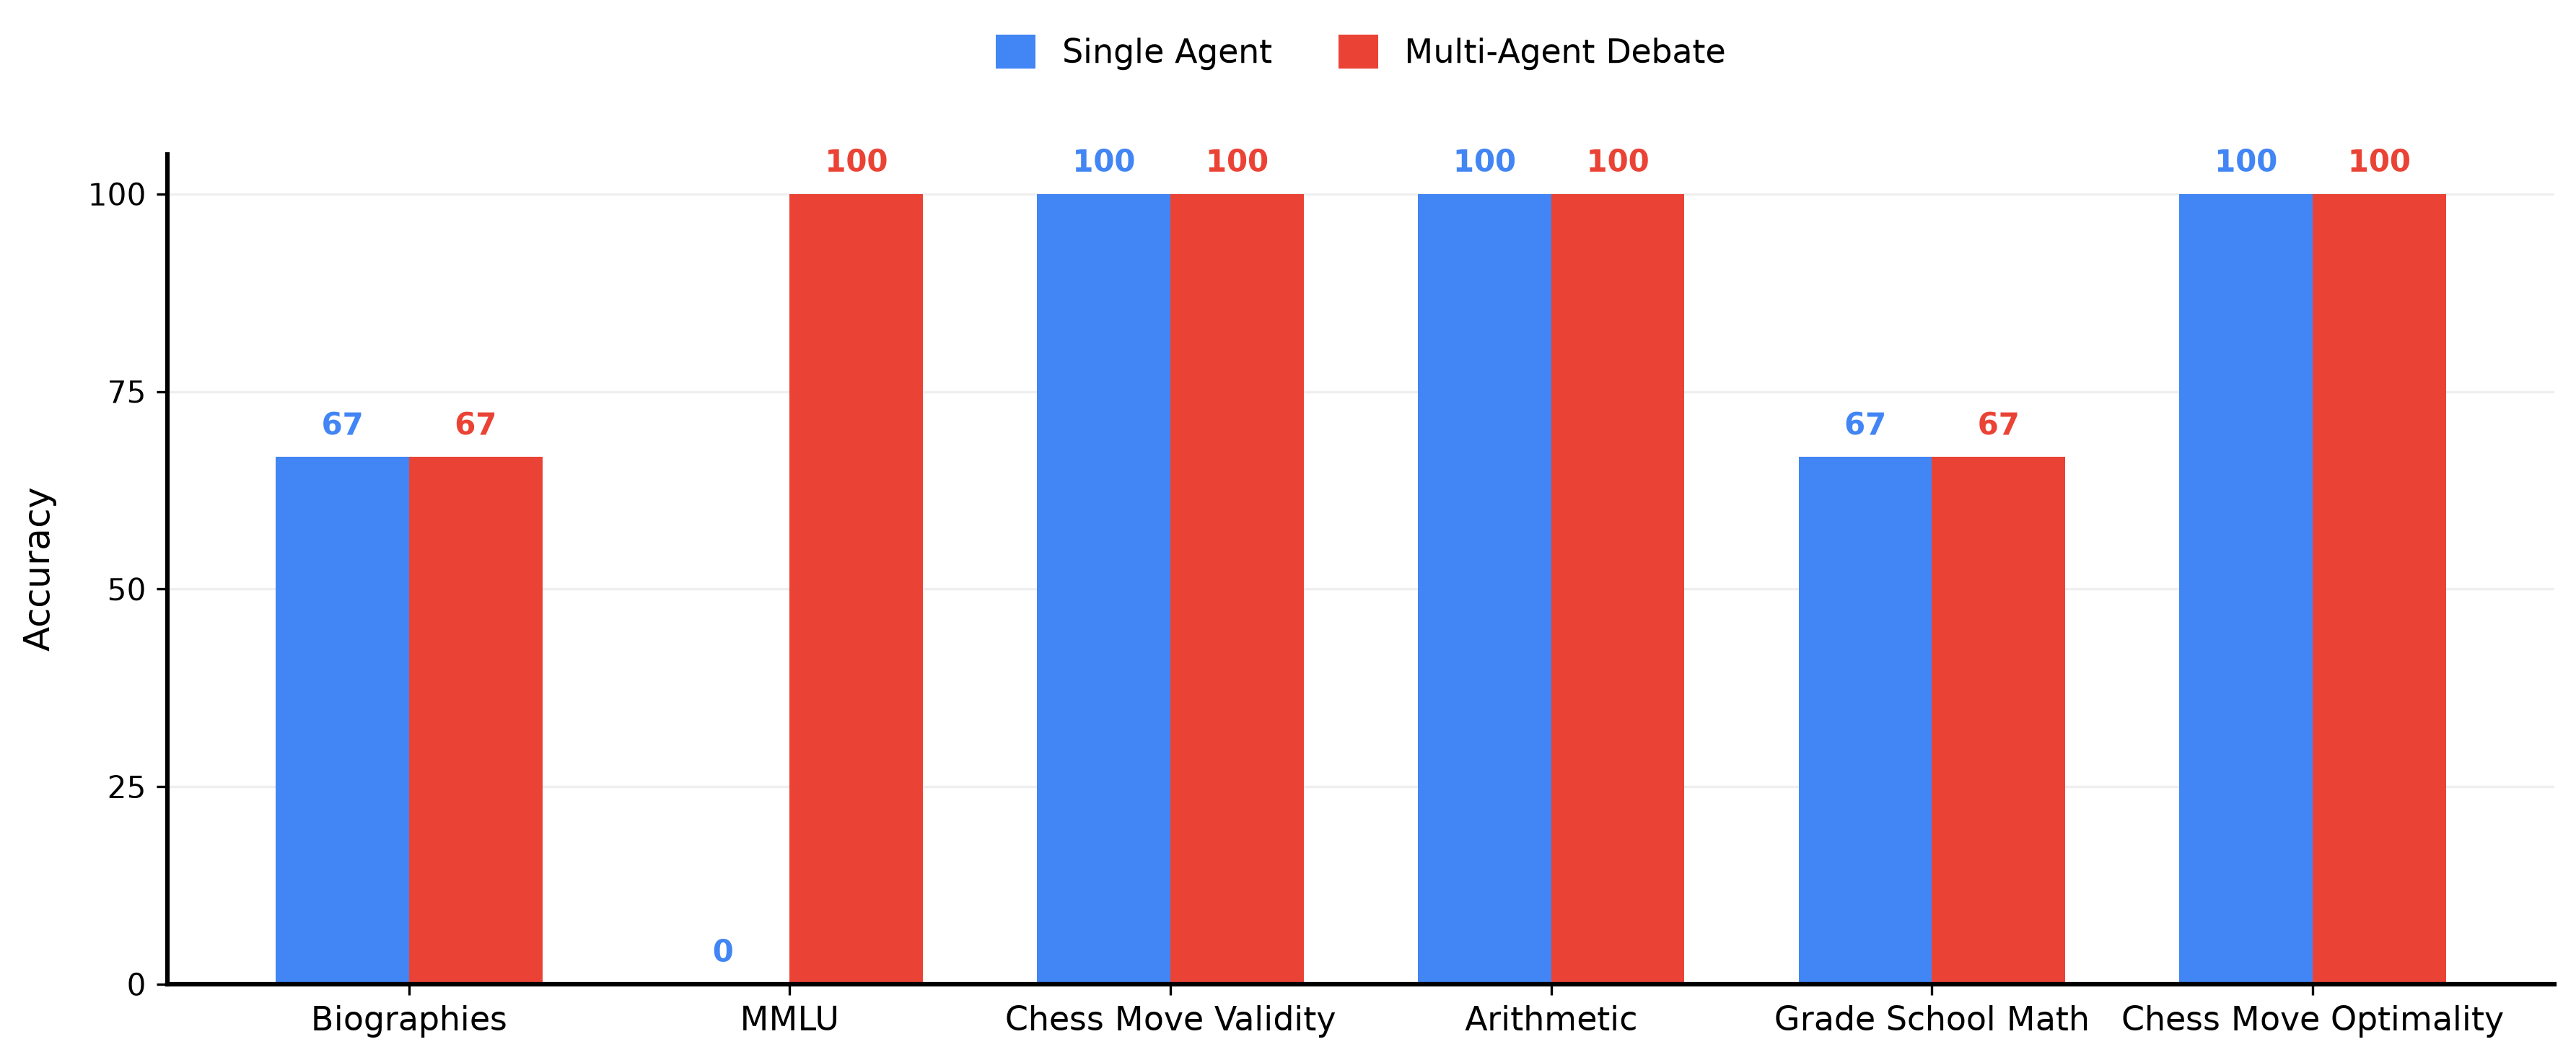

In [7]:
fig_barchart = visualizer.plot_accuracy_comparison(benchmark_results)

## 5. Academic Publication-Grade Comparison Table
Generating the LaTeX academic paper table displaying accuracy and standard deviation (`mean ± std`) for each strategy derived strictly from your dataset evaluation.

Academic table image successfully saved to results/graphs\academic_comparison_table.png


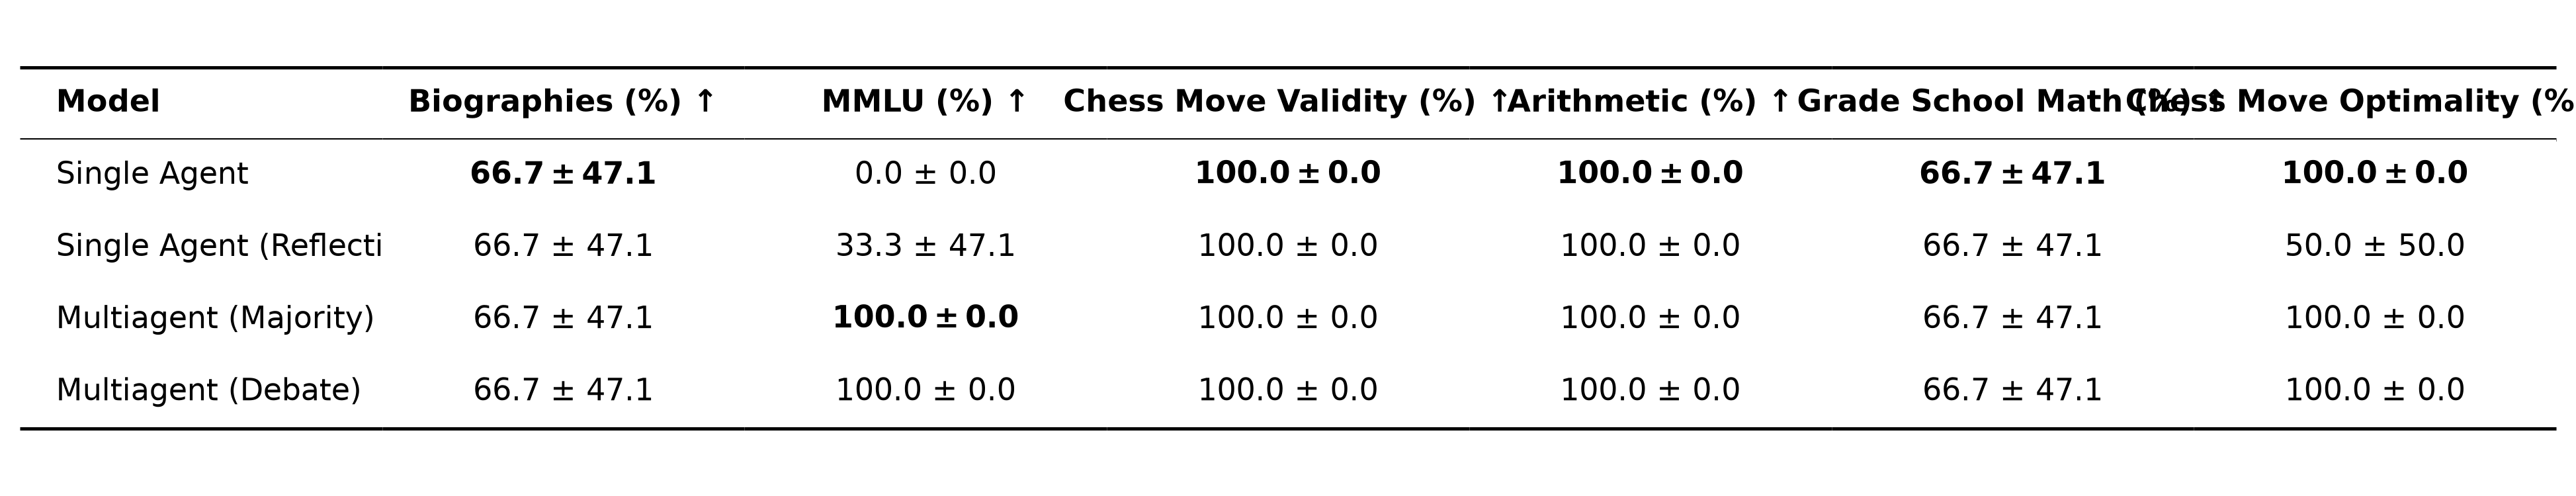

In [8]:
df_table, fig_table = visualizer.generate_paper_styled_table(benchmark_results)


# # Display Publication Table Image
# fig_table

## 6. Summary of Evaluation Results
Reviewing dataset-level performance gains, consensus confidence, and error-correction accuracy from the multi-agent debate workflow.

In [9]:
from models.health_check import run_all_health_checks
await run_all_health_checks()

Running LLM Health Checks...
Agent : agent_1
Model : llama-3.3-70b-versatile
Status: Healthy
----------------------------------------
Agent : agent_2
Model : qwen/qwen-2.5-72b-instruct
Status: Healthy
----------------------------------------
Agent : agent_3
Model : llama-3.1-8b-instant
Status: Healthy
----------------------------------------
Agent : agent_judge
Model : llama-3.3-70b-versatile
Status: Healthy
----------------------------------------
